In [ ]:
#import thinkplot
#import thinkstats2
import pandas as pd
import numpy as np
import math
import scipy.stats as ss
import thinkplot
import thinkstats2

##Seaborn for fancy plots. 
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (15,5)

<h1>Assignment 2: Life Expectancy and You!</h1>

<b>Instructions:</b>
<ul>
<li>Use the worksheet below to act as a guide to exploring and examining the data in the dataset.
<li>Try to make things easy to read. Look at the formatting stuff above. 
<li>As long as you do what is asked, you can do things in many different ways. You may need to do a little searching. 
</ul>

### Please Use Formatting to Make it Clear What I Should be Looking at! Please!!! I Beg You!!!

In [183]:
#Load data and do some cleanup before starting
#Please don't change this stuff. 
dfLE = pd.read_csv("led.csv")
dfLE.rename(columns={"Status":"isDeveloped", }, inplace=True)
dfLE["isDeveloped"].replace(('Developed', 'Developing'), (1, 0), inplace=True)
dfLE = dfLE.drop(columns={"Year", "Incomecompositionofresources", "thinness5-9years", "HIV/AIDS", "percentageexpenditure", "Totalexpenditure", "thinness1-19years"})
dfLE = dfLE.groupby("Country", as_index=False).mean()
dfLE.head()


C:\Users\monic\AppData\Local\Temp\ipykernel_24448\1330392595.py:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\monic\AppData\Local\Temp\ipykernel_24448\1330392595.py:5: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,Country,isDeveloped,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,HepatitisB,Measles,BMI,under-fivedeaths,Polio,Diphtheria,GDP,Population,Schooling
0,Afghanistan,0.0,58.19375,269.0625,78.2500,0.014375,64.562500,2362.2500,15.51875,107.5625,48.3750,52.3125,4.136734e+09,9.972260e+06,8.21250
1,Albania,0.0,75.15625,45.0625,0.6875,4.848750,98.000000,53.3750,49.06875,0.9375,98.1250,98.0625,1.166938e+09,6.969116e+05,12.13750
2,Algeria,0.0,73.61875,108.1875,20.3125,0.406667,78.000000,1943.8750,48.74375,23.5000,91.7500,91.8750,7.345597e+10,2.164983e+07,12.71250
3,Angola,0.0,49.01875,328.5625,83.7500,5.740667,70.222222,3561.3125,18.01875,132.6250,46.1250,47.6875,2.177835e+10,1.014710e+07,8.04375
4,AntiguaandBarbuda,0.0,75.05625,127.5000,0.0000,7.949333,98.266667,0.0000,38.42500,0.0000,96.9375,98.3125,0.000000e+00,NaN,8.84375


<h2>Part 1: Add a column for GDP per Capita (5pts)</h2>

Show print the labels along with just that column. Print 10 random rows of that data. 

Note: you'll have to look at the units to ensure you get it right. 

In [189]:
#Part 1

dfLE["GDP"] = pd.to_numeric(dfLE["GDP"], errors="coerce")
dfLE["Population"] = pd.to_numeric(dfLE["Population"], errors="coerce")

# Calculate GDP/Capita
dfLE["GDP/Capita"] = (dfLE["GDP"] * 1e6) / dfLE["Population"]

# Select columns
gdp_capita_df = dfLE[["Country", "GDP/Capita"]].dropna()

# Format and display 10 random countries 
styled_table = (
    gdp_capita_df.sample(10, random_state=42)             
    .style
    .set_caption("GDP per Capita by Country – Sample of 10")
    .format({"GDP/Capita": "${:,.2f}"})                   
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "14px"), ("font-weight", "bold"),
                   ("text-align", "center"), ("padding", "6px 0")]},
        {"selector": "th",
         "props": [("background-color", "#4C93AF"),
                   ("color", "white"), ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "center")]}
    ])
    .background_gradient(subset=["GDP/Capita"], cmap="Blues")
)

display(styled_table)

,Country,GDP/Capita
155,SolomonIslands,"$996,233,268.65"
25,BurkinaFaso,"$396,575,578.20"
104,Malta,"$10,303,379,673.11"
124,Norway,"$26,681,567,884.40"
73,Honduras,"$1,508,150,265.40"
16,Belize,"$4,243,835,641.79"
172,Tonga,"$1,566,375,409.63"
83,Jamaica,"$2,236,880,556.78"
84,Japan,"$26,118,797,585.07"
24,Bulgaria,"$5,490,517,494.00"


### Part 2: Print a visualization of each distribution. Both regular (density) and cumulative. (15pts)

Print each distribution is some type of visualization, also print the cumulative distribution. 
<ul>
<li>5 points are for using some visualization that is effective.
<li>5 points for formatting things in a nice layout. Hint: for whatever chart you use, look into some formatting options. Think of what to try to Google for an example for printing multiple charts, a grid of charts, etc... and try to adapt one to yours. There is also a way to do it using some thinkstats/thinkplot stuff. 
<li><b>5 points are for doing it in an efficient way - just listing off each column is lots of typing... Remember, the #1 trait of programmers is laziness with respect to repetitive tasks. If we are doing the same thing over and over with tiny changes, try to think of a condensed way to do this...</b>
</ul>

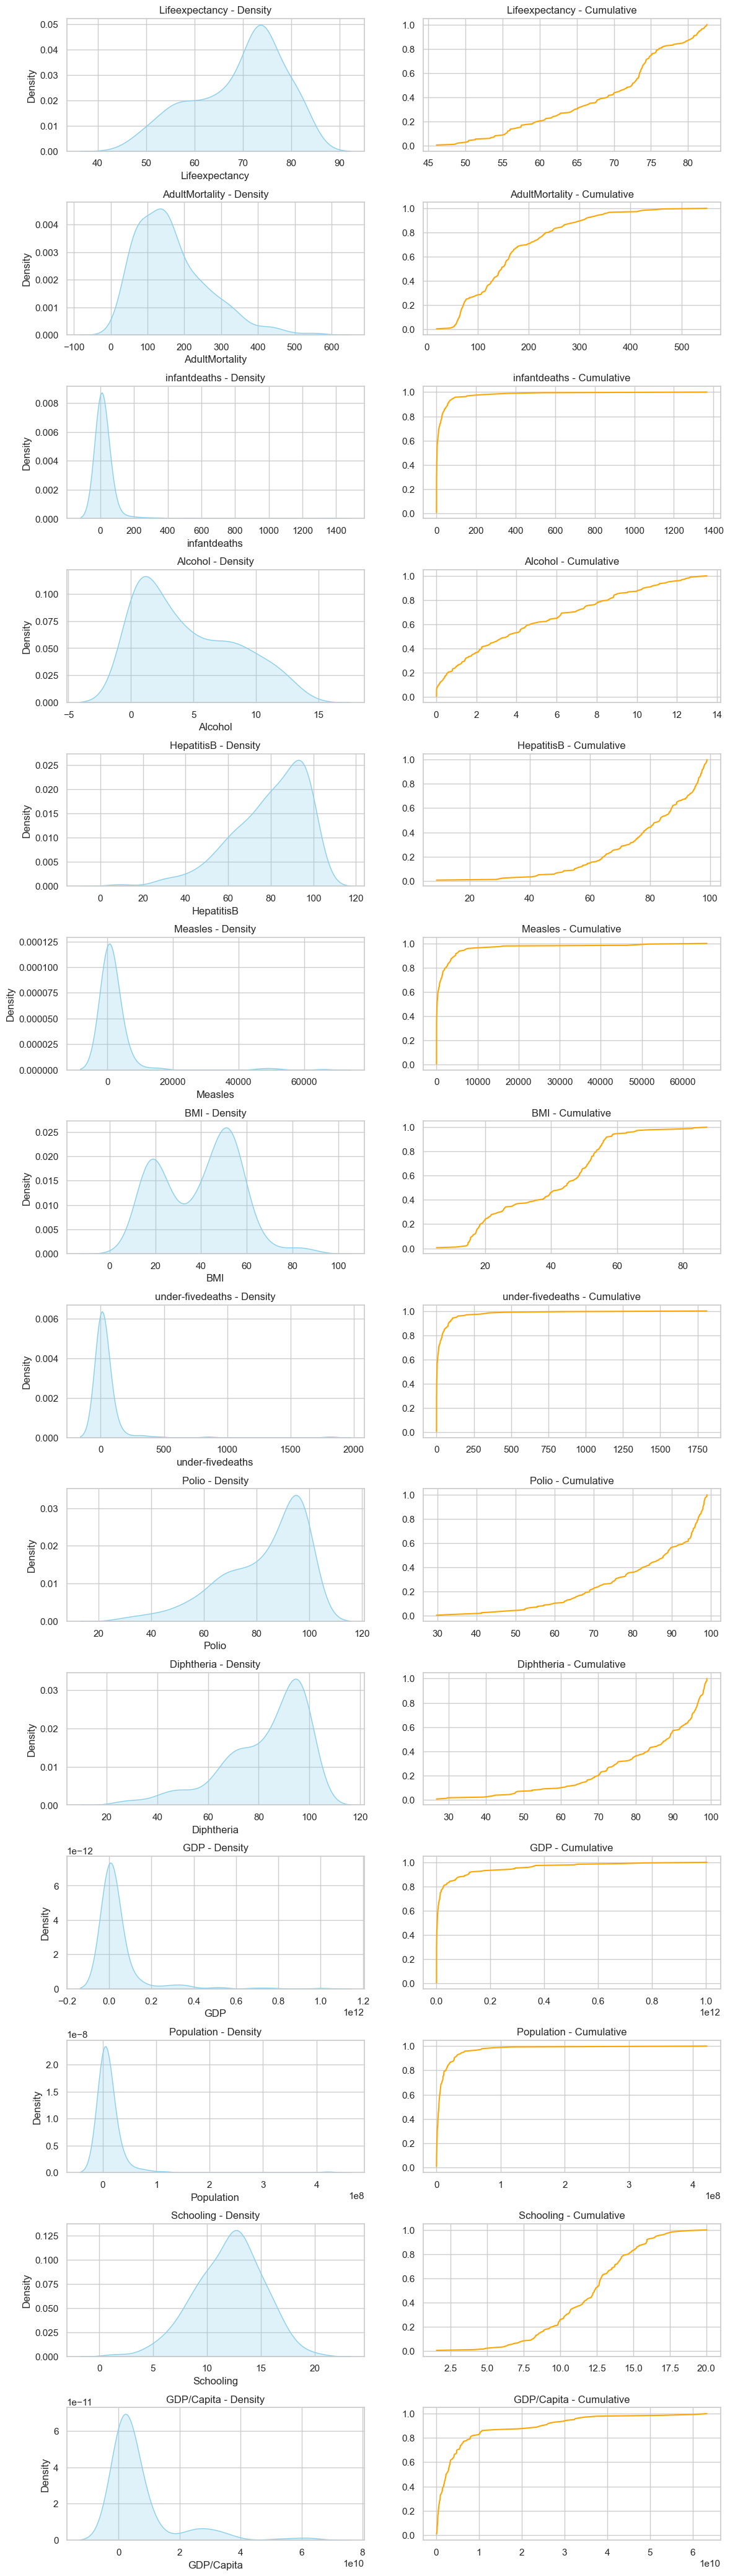

In [ ]:
#Print all distributions

numeric_cols = ["Lifeexpectancy", "AdultMortality", "infantdeaths", "Alcohol",
    "HepatitisB", "Measles", "BMI", "under-fivedeaths", "Polio",
    "Diphtheria", "GDP", "Population", "Schooling", "GDP/Capita"]


def plot_distribution(df, col, ax_density, ax_cdf):
    """Plot density and cumulative distribution for a column."""
    # Drop NaN values
    data = df[col].dropna()
    
    # Density plot 
    sns.kdeplot(data, ax=ax_density, fill=True, color='skyblue')
    ax_density.set_title(f"{col} - Density")
    
    # Cumulative distribution plot
    sorted_data = data.sort_values()
    cdf = sorted_data.rank(method='first') / len(sorted_data)
    ax_cdf.plot(sorted_data, cdf, color='orange')
    ax_cdf.set_title(f"{col} - Cumulative")

num_cols = len(numeric_cols)
fig, axes = plt.subplots(num_cols, 2, figsize=(12, num_cols*3))
plt.tight_layout(pad=3)

for i, col in enumerate(numeric_cols):
    ax_density = axes[i, 0]
    ax_cdf = axes[i, 1]
    plot_distribution(dfLE, col, ax_density, ax_cdf)

plt.show()

### Create an analytical distribution for SCHOOLING, and use it for a couple of things. (20pts)

<ul>
<li>5 points are for choosing an appropriate distribution. Please state it clearly somewhere.
<li>10 points are for creating and visualizing the distribution. Do it <b>without</b> using a fit() method. Plot the emperical data on the same graph as the analytical distribution. 
<li>5 points are for using the distribution to predict the percentage of that have a schooling level within 1 year of Canada. 
</ul>

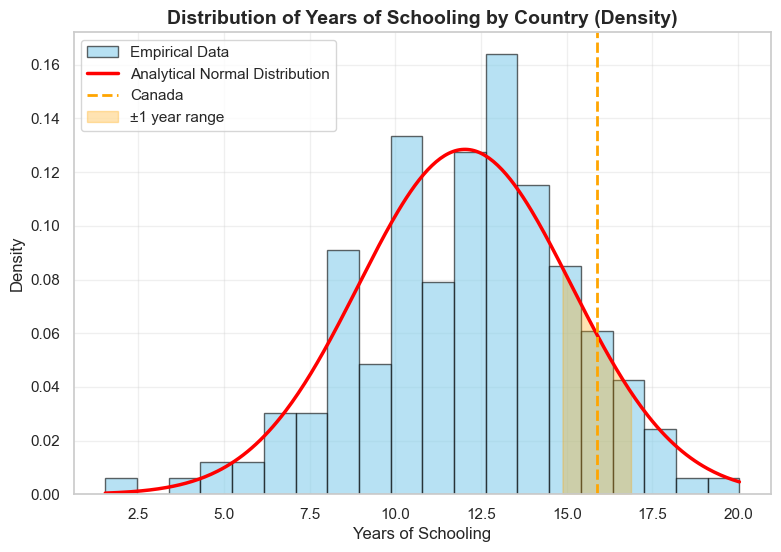

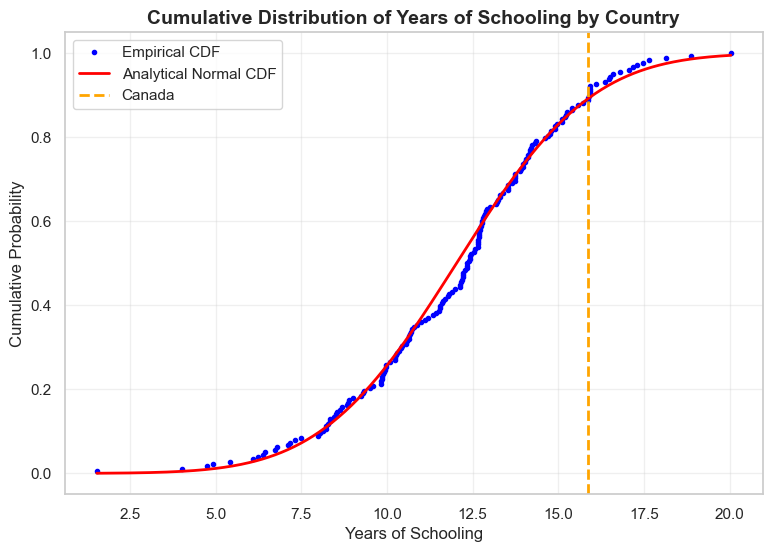

Mean (μ): 12.03
Standard Deviation (σ): 3.10
Canada: 15.88 years
Percentage of countries within ±1 year of Canada: 12.03%


In [221]:
#Analytical for Schooling
from scipy.stats import norm

# Schooling Dataset
schooling = dfLE["Schooling"].dropna()
canada_schooling = dfLE.loc[dfLE["Country"] == "Canada", "Schooling"].values[0]

# Analytical Norm Distribution
mu = np.mean(schooling)
sigma = np.std(schooling, ddof=1)
x = np.linspace(min(schooling), max(schooling), 300)
pdf = norm.pdf(x, mu, sigma)
cdf = norm.cdf(x, mu, sigma)

# Density Visualization
plt.figure(figsize=(9,6))
plt.hist(schooling, bins=20, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Empirical Data')
plt.plot(x, pdf, 'r-', lw=2.5, label='Analytical Normal Distribution')
plt.axvline(canada_schooling, color='orange', linestyle='--', lw=2, label='Canada')

# ±1 year Canada
lower, upper = canada_schooling - 1, canada_schooling + 1
x_fill = np.linspace(lower, upper, 200)
y_fill = norm.pdf(x_fill, mu, sigma)
plt.fill_between(x_fill, y_fill, color='orange', alpha=0.3, label='±1 year range')

plt.title("Distribution of Years of Schooling by Country (Density)", fontsize=14, weight='bold')
plt.xlabel("Years of Schooling")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Cumulative Distribution Visualization
sorted_schooling = np.sort(schooling)
empirical_cdf = np.arange(1, len(sorted_schooling)+1) / len(sorted_schooling)

plt.figure(figsize=(9,6))
plt.plot(sorted_schooling, empirical_cdf, 'b.', label='Empirical CDF')
plt.plot(x, cdf, 'r-', lw=2, label='Analytical Normal CDF')
plt.axvline(canada_schooling, color='orange', linestyle='--', lw=2, label='Canada')
plt.title("Cumulative Distribution of Years of Schooling by Country", fontsize=14, weight='bold')
plt.xlabel("Years of Schooling")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

prob = norm.cdf(upper, mu, sigma) - norm.cdf(lower, mu, sigma)

print(f"Mean (μ): {mu:.2f}")
print(f"Standard Deviation (σ): {sigma:.2f}")
print(f"Canada: {canada_schooling:.2f} years")
print(f"Percentage of countries within ±1 year of Canada: {prob*100:.2f}%")

### Part 3: Create another analytical distribution for GDP per Capita (20pts)

<ul>
<li>5 points are for choosing an appropriate distribution. Please state it clearly somewhere.
<li>10 points are for creating and visualizing it alongside the emperical. You have free reign on how. 
<li>5 points are for using the analytical distribution to evaluate the quality of your GDP per capita metric - does it appear accurate? Why or why not?
<li>If you've judged GDP per cap to be unreliable, drop it. 
</ul>

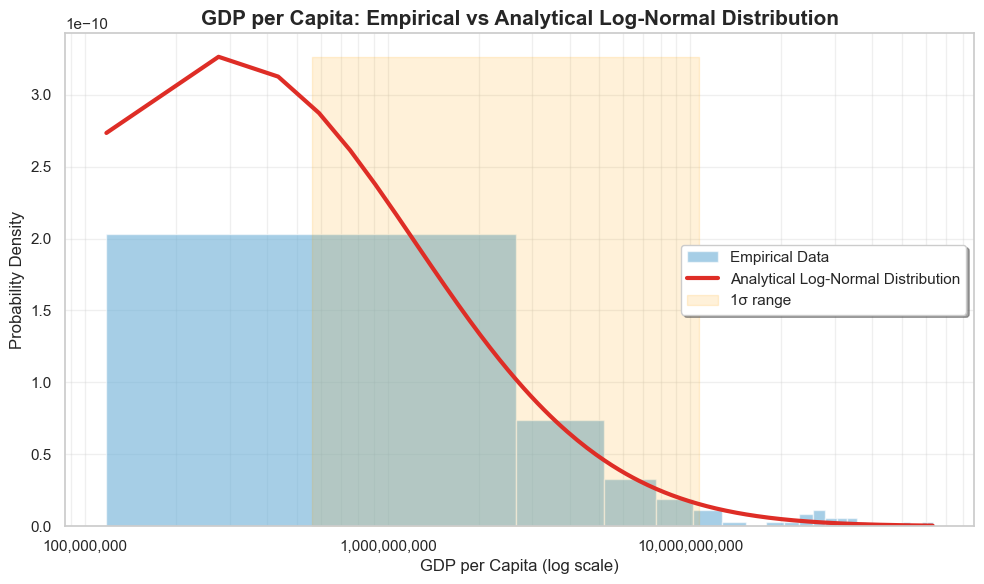

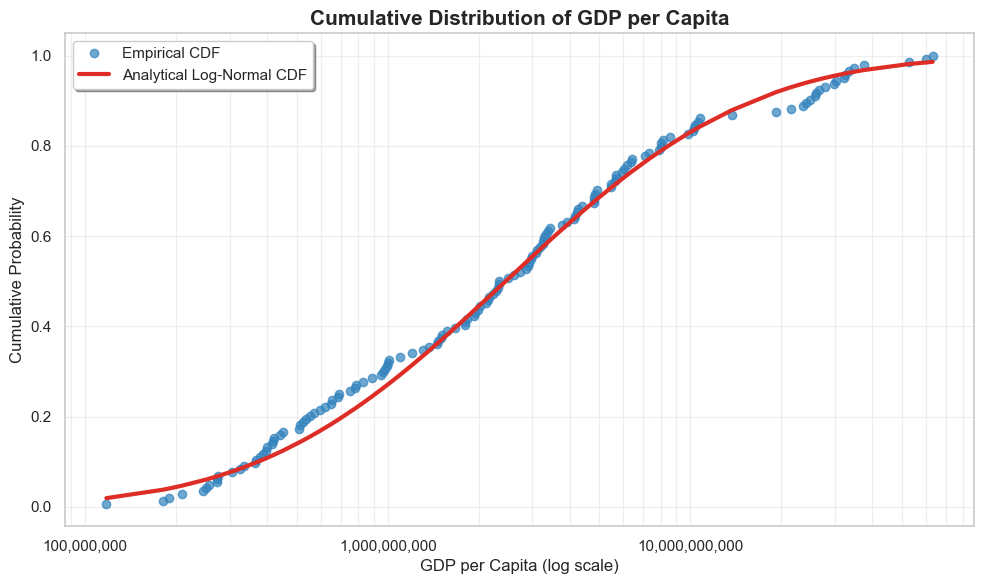

In [224]:
#Analytical for GDP/capita
from scipy.stats import lognorm

gdp_cap = dfLE["GDP/Capita"].dropna()
gdp_cap = gdp_cap[gdp_cap > 0]

log_gdp = np.log(gdp_cap)
mu = np.mean(log_gdp)
sigma = np.std(log_gdp, ddof=1)
x = np.linspace(min(gdp_cap), max(gdp_cap), 400)
pdf = lognorm.pdf(x, s=sigma, scale=np.exp(mu))

# ----------- STYLISH PDF PLOT -----------
plt.figure(figsize=(10,6))
plt.hist(gdp_cap, bins=25, density=True, alpha=0.6, color="#6baed6", edgecolor='white', label='Empirical Data')
plt.plot(x, pdf, color="#de2d26", lw=3, label='Analytical Log-Normal Distribution')

# Optional shaded "typical" region
plt.fill_betweenx([0, max(pdf)], np.exp(mu - sigma), np.exp(mu + sigma),
                  color='orange', alpha=0.15, label='1σ range')

plt.xscale('log')
plt.title("GDP per Capita: Empirical vs Analytical Log-Normal Distribution", fontsize=15, weight='bold')
plt.xlabel("GDP per Capita (log scale)", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.legend(frameon=True, facecolor='white', shadow=True)
plt.grid(alpha=0.3, which='both')
def comma_formatter(x, pos):
    return f"{int(x):,}"

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(comma_formatter))

plt.tight_layout()
plt.show()

# CDF Plot
sorted_gdp = np.sort(gdp_cap)
empirical_cdf = np.arange(1, len(sorted_gdp)+1) / len(sorted_gdp)
cdf = lognorm.cdf(sorted_gdp, s=sigma, scale=np.exp(mu))

plt.figure(figsize=(10,6))
plt.plot(sorted_gdp, empirical_cdf, 'o', color="#3182bd", alpha=0.7, label='Empirical CDF')
plt.plot(sorted_gdp, cdf, color="#de2d26", lw=3, label='Analytical Log-Normal CDF')

plt.xscale('log')
plt.title("Cumulative Distribution of GDP per Capita", fontsize=15, weight='bold')
plt.xlabel("GDP per Capita (log scale)", fontsize=12)
plt.ylabel("Cumulative Probability", fontsize=12)
plt.legend(frameon=True, facecolor='white', shadow=True)
plt.grid(alpha=0.3, which='both')
def comma_formatter(x, pos):
    return f"{int(x):,}"

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(comma_formatter))

plt.tight_layout()
plt.show()


### Is it accurate?

The Log Normal Distribution is accurate and reliable as most countries are in the lower to middle GDP/Capital, there are fewer countries that are extremely wealthy which skews the distribution to the right. 

### Part 4: Visually identify correlations. Separate developed and not developed countries is some way. (15pts)

<ul>
<li>5 points are for effectively and clearly showing the visualizations used to evaluate correlations.
<li>10 points are for, in the process of visualizing, remove outliers that confound correlations. List outlier "filters" you used and justify why - was the data an error, a real value that is just way out of line, or somethingn else? Remember, you're trying to find things that have correlations with each other. Looking at a correlation between home size and income may not benefit from Jeff Bezos being included. It may be helpful to look at the results and revise. 
</ul>

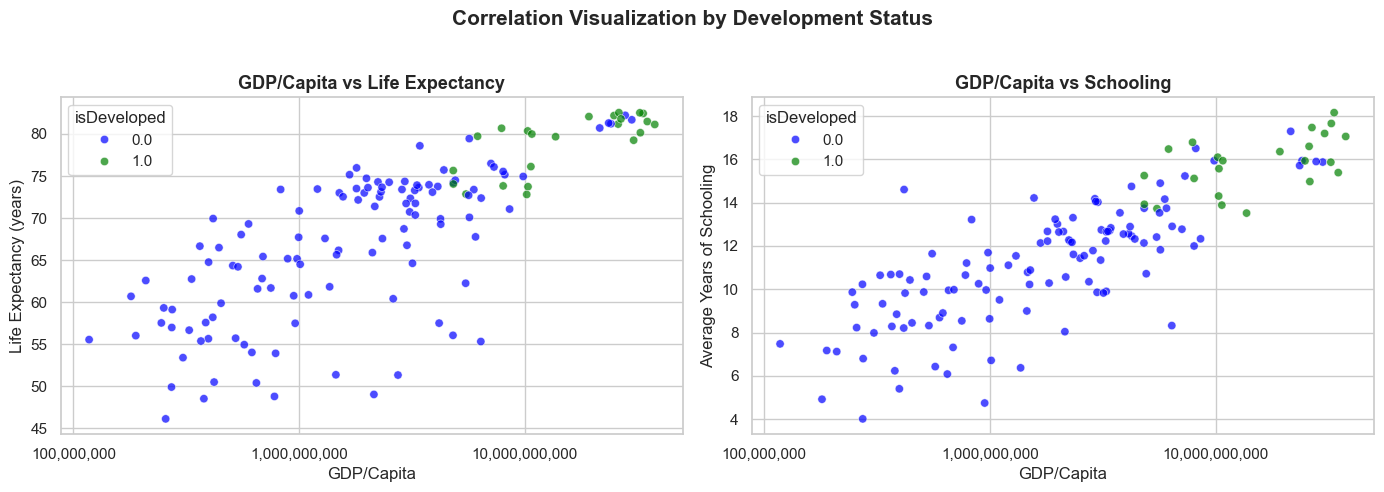

Remaining countries after cleaning: 69


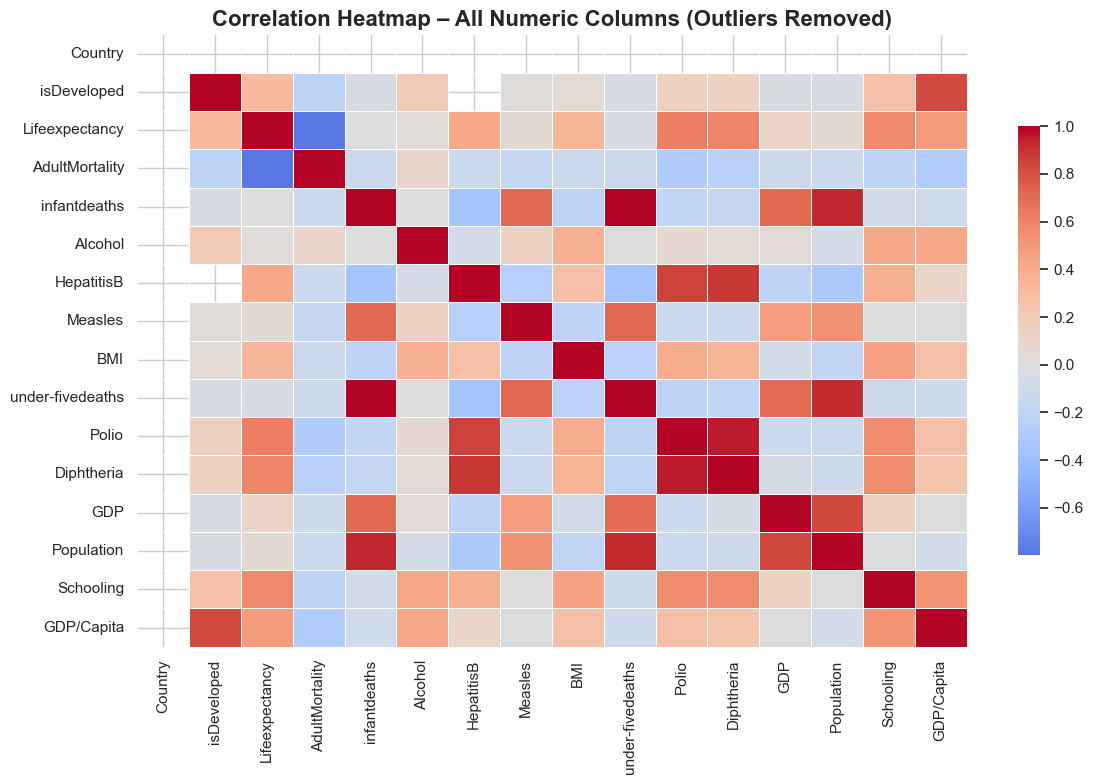

In [238]:
#Visualize correlations. 

df_corr = dfLE.copy()
df_corr["GDP/Capita"]      = pd.to_numeric(df_corr["GDP/Capita"], errors='coerce')
df_corr["Lifeexpectancy"] = pd.to_numeric(df_corr["Lifeexpectancy"], errors='coerce')
df_corr["Schooling"]      = pd.to_numeric(df_corr["Schooling"], errors='coerce')
df_corr = df_corr.dropna(subset=["GDP/Capita", "Lifeexpectancy", "Schooling", "isDeveloped"])

# ---------- 2. Outlier filters ----------
upper_gdp_limit = df_corr["GDP/Capita"].quantile(0.98)
df_corr = df_corr[df_corr["GDP/Capita"] < upper_gdp_limit]                     # extreme wealth nations removed
df_corr = df_corr[(df_corr["Lifeexpectancy"].between(40, 90))]                # unrealistic low/high removed
df_corr = df_corr[(df_corr["Schooling"].between(4, 20))]                      # implausible schooling filtered

# ---------- 3. Visualization ----------

def comma_formatter(x, pos):
    return f"{int(x):,}"

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# GDP/Capita vs Life Expectancy
sns.scatterplot(data=df_corr, x="GDP/Capita", y="Lifeexpectancy", hue="isDeveloped",
                palette={1.0:"green", 0.0:"blue"}, alpha=0.7, ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("GDP/Capita vs Life Expectancy", fontsize=13, weight='bold')
axes[0].set_xlabel("GDP/Capita")
axes[0].set_ylabel("Life Expectancy (years)")
axes[0].xaxis.set_major_formatter(FuncFormatter(comma_formatter))  # 👈 format x-axis

# GDP/Capita vs Schooling
sns.scatterplot(data=df_corr, x="GDP/Capita", y="Schooling", hue="isDeveloped",
                palette={1.0:"green", 0.0:"blue"}, alpha=0.7, ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("GDP/Capita vs Schooling", fontsize=13, weight='bold')
axes[1].set_xlabel("GDP/Capita")
axes[1].set_ylabel("Average Years of Schooling")
axes[1].xaxis.set_major_formatter(FuncFormatter(comma_formatter))  # 👈 format x-axis

plt.suptitle("Correlation Visualization by Development Status", fontsize=15, weight='bold')
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()



df_corr = dfLE.copy()
df_corr = df_corr.apply(pd.to_numeric, errors='coerce')

# Outliers filter
filters = (
    (df_corr["GDP/Capita"] < df_corr["GDP/Capita"].quantile(0.98)) &  # remove extreme GDP
    (df_corr["Lifeexpectancy"].between(40, 90)) &                    # biological realism
    (df_corr["Schooling"].between(4, 20)) &                          # plausible schooling
    (df_corr["BMI"].between(10, 40)) &                               # valid BMI range
    (df_corr["Alcohol"] < df_corr["Alcohol"].quantile(0.98))         # remove alcohol outliers
)
df_corr = df_corr[filters].dropna(subset=["isDeveloped"])

print(f"Remaining countries after cleaning: {len(df_corr)}")


# Heatmap of all countries and GDP/Capita 
numeric_df = df_corr.select_dtypes(include=[np.number]).drop(columns=['GDPperCapita'], errors='ignore')
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidths=0.4, cbar_kws={'shrink':0.7})
plt.title("Correlation Heatmap – All Numeric Columns (Outliers Removed)",
          fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


### Outliers Filters 

Outlier filters were put on:
    - GDP/Capital < 98 percntile to remove extremely weather countries as they can affect the graphs. 
    - Lifeexpectancy 40-90, as this age range is more relative to actual life expectancies and removes any innaccurate values. 
    - Schooling 4-20, this is a typical schooling range and filters out any extreme values. 
    - BMI 10-40, filters on more accurate human BMI scale.
    - Alcohol < 98th percentile, removes any extreme values which can cause skewing. 

Evaluating the graphs we can see a big correlation between GDP/Capital vs Life expectancy and GDP/Capital vs Schooling in develeoped (green) vs not developed countries (blue). This tells us that countries that are not developed have lower GDP/Capita, life expectancys and schooling where are countries that are developed have higher GDP/Capital, life expectancy and schooling. 



### Part 5: Calculate correlations (25pts)

<ul>
<li>5 points are for identifying and calculating 3 strongest correlations with life expectancy for each of developed and not developed. 
<li>10 points are for analyzing those correlations. Do they appear to be supported by reality? Do you have reason to beleive any are causal?
<li>10 points are for identifying 2 places where developing and developed countries have a substantially different relationship with respect to life expectancy, and theorizing why. What would be needed to confirm your thoughts?
</ul>

<b>Please put your written parts in markdown cells, with a little formatting to make them readable. 

In [239]:
#Calculate correlations and analyze. 
from IPython.display import display

# --- Prepare data ---
df_corr = dfLE.copy()
df_corr = df_corr.apply(pd.to_numeric, errors='coerce')

# Split groups
dev = df_corr[df_corr["isDeveloped"] == 1.0]
not_dev = df_corr[df_corr["isDeveloped"] == 0.0]

# Compute correlations with Lifeexpectancy
corr_dev = dev.corr()["Lifeexpectancy"].sort_values(ascending=False)
corr_not_dev = not_dev.corr()["Lifeexpectancy"].sort_values(ascending=False)

# Extract top 3 (skip self-correlation)
top3_dev = corr_dev.dropna().iloc[1:4].reset_index()
top3_not_dev = corr_not_dev.dropna().iloc[1:4].reset_index()
top3_dev.columns = ["Variable", "Correlation (Developed)"]
top3_not_dev.columns = ["Variable", "Correlation (Developing)"]

# --- Styled displays ---
styled_dev = (
    top3_dev.style
    .set_caption("Top 3 Correlations with Life Expectancy – Developed Countries")
    .format({"Correlation (Developed)": "{:.3f}"})
    .set_table_styles([
        {"selector":"caption","props":[("font-size","14px"),("font-weight","bold"),("text-align","center")]},
        {"selector":"th","props":[("background-color","#81BE9A"),("color","white"),("text-align","center")]},
        {"selector":"td","props":[("text-align","center")]}
    ])
    .background_gradient(axis=None, cmap="Greens")
)

styled_not_dev = (
    top3_not_dev.style
    .set_caption("Top 3 Correlations with Life Expectancy – Developing Countries")
    .format({"Correlation (Developing)": "{:.3f}"})
    .set_table_styles([
        {"selector":"caption","props":[("font-size","14px"),("font-weight","bold"),("text-align","center")]},
        {"selector":"th","props":[("background-color","#6896C5"),("color","white"),("text-align","center")]},
        {"selector":"td","props":[("text-align","center")]}
    ])
    .background_gradient(axis=None, cmap="Blues")
)

display(styled_dev)
display(styled_not_dev)

,Variable,Correlation (Developed)
0,GDP/Capita,0.629
1,Schooling,0.418
2,GDP,0.372


,Variable,Correlation (Developing)
0,Schooling,0.736
1,BMI,0.695
2,Diphtheria,0.650


### Correlations

Top 3 Developed Countries 
- GDP/Capita has a strong correlation with life expectancy because countries that have higher GDP/Capita usually have higher life expectancys this is due to more availabilty of nutritrious foods, and easier access to health care. 
- Schooling has a moderate correlation with life expectancy because having more years of education often leads to better financial stability and is more informitive. 
- GDP has a moderate correlation with life expectancy because the countries overall wealth still contributes, some countries offer free health care. 

Top 3 Developing Countries
- Schooling has a strong correlation with life expectancy because higher education provides economic stability which contributes to what groceries can be bought to eat and live a healthy life. 
- BMI has a strong correlation as developing countries have less access to safe a nutritious food options, undernutrition is a big contributor to early mortality. 
- Diptheria has a strong correlation with life expectancy as developing countries have less access to health care and are more prone to catching diptheria, no health care means no vaccinations which means higher chance of mortality. 

These correlations align with reality as developed countries typically have stronger economies, even after basic needs are met for most of the population extra earnings are just a benefit. Developing countries rely on basic health and education where even the smallest advancements in schooling, vaccination and nutrtiton can greatly extend lifespan. 

Two places where developed and developing countries differ are:
1. GDP/Capita differs because the population in developed countries have higher income and once they reach a certain threshold and basic life needs are met, having extra income wont increase lifespan. Where GDP/Capital in developing countries have a positive correlation with life expectancy, so having an increase in income can drastically impove ones life. 
2. BMI differs because developed countries have a weak correlation with life expectancy. They typically have safe and better nutritional food options as well as health care that is private or publicly funded, this means they have easier access to medical help. In developing countries BMI has a stronger correlation because they have less safe food options, where populations are more dense the BMI correlation is higher, less food more people not enough for survival. 